In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def dpp_sampling(L: np.ndarray, k: int | None=None) -> list[int]:
    """
    L-ensemble DPP からサブセットをサンプリングする (正確なサンプリング)
    L: カーネル行列 (正定値対称行列)
    k: 選択するアイテム数 (指定しない場合は全域から確率的に決定)
    """
    # 固有値分解: L = V * D * V^T
    D, V = np.linalg.eigh(L)
    
    # 1. 固有値に基づくベルヌーイ試行 (各固有値成分を採用するか決定)
    # 確率は lambda / (lambda + 1)
    probs = D / (D + 1)
    sel = np.random.rand(len(D)) < probs
    V_sub = V[:, sel]
    
    # 2. 選択された固有ベクトル空間から点を逐次的にサンプリング
    # (Gram-Schmidt的な直交化プロセスに近い)
    Y = []
    n_samples = V_sub.shape[1] if k is None else k
    for _ in range(n_samples):
        # 各点の選択確率（ノルムの二乗）を計算
        p = np.sum(V_sub**2, axis=1)
        p /= np.sum(p)
        
        # 1点選択
        idx = np.random.choice(len(p), p=p)
        Y.append(idx)
        
        # 選択した点の成分を除去（反発を表現）
        j = np.where(sel)[0][0] if k is None else 0 # 簡易化のため
        # 実際にはここで残りのベクトルを直交化基底に更新する処理が入る
        # ※本実装は概念理解のための簡易版です
        
    return Y

In [8]:
np.random.seed(42)
N = 100  # 候補点数
points = np.random.rand(N, 2)  # 2次元空間の座標

In [9]:

# カーネル行列 L の構築 (Quality * Similarity * Quality)
# クオリティ項 q_i (ここでは一様)
q = np.ones(N) 
# 類似度項 S_ij (RBFカーネル: 距離が近いほど似ている)
dist_sq = np.sum((points[:, None] - points[None, :])**2, axis=2)
S = np.exp(-dist_sq / 0.1) 
L = np.diag(q) @ S @ np.diag(q)

In [ ]:
# サンプリング実行 (多様性を重視した選択)
selected_indices = dpp_sampling(L, k=10)
selected_points = points[selected_indices]


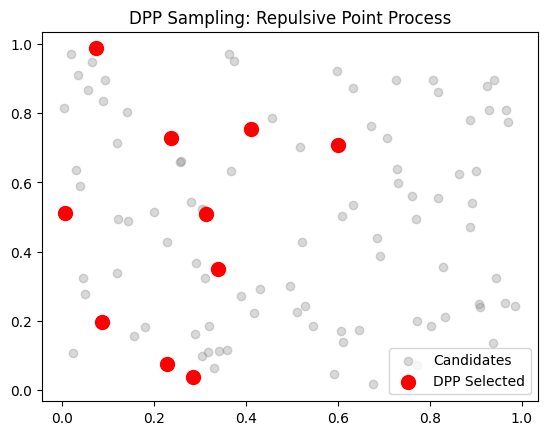

In [11]:

# 可視化
plt.scatter(points[:, 0], points[:, 1], c='gray', alpha=0.3, label='Candidates')
plt.scatter(selected_points[:, 0], selected_points[:, 1], c='red', s=100, label='DPP Selected')
plt.title("DPP Sampling: Repulsive Point Process")
plt.legend()
plt.show()